# Baseline Modeling cho bài toán Next-Time Prediction

Notebook này không nhằm xây dựng một mô hình cuối thật mạnh ngay lập tức. Mục tiêu của notebook là thiết lập các baseline đáng tin cậy cho bài toán dự đoán thời gian tới sự kiện tiếp theo (`next-time prediction`) trong dữ liệu recommender/event-sequence.

Câu hỏi nghiên cứu chính là:

> Các mô hình học máy đơn giản có vượt được baseline thống kê trong bài toán dự đoán thời gian sự kiện tiếp theo không?

Notebook này đóng vai trò cầu nối giữa bước kiểm tra tính khả thi dữ liệu và các mô hình mạnh hơn ở giai đoạn sau. Vì vậy, mục đích không phải là tối đa hóa metric bằng mọi giá. Metric thấp hoặc chưa hoàn hảo vẫn chấp nhận được nếu cách đánh giá sạch, temporal split hợp lý, và so sánh với baseline đủ thuyết phục.

## Thiết kế thí nghiệm

Last.fm được dùng chủ yếu cho regression vì listening logs có timestamp tương đối có ý nghĩa cho hành vi tiêu thụ theo thời gian. Target regression là `log1p(delta_t)`, trong đó `delta_t` là khoảng cách thời gian giữa event hiện tại và event kế tiếp.

RetailRocket và Taobao được dùng chủ yếu cho time-bucket classification vì thời điểm event trong e-commerce thường nhiễu, nhiều cụm, và khó dự đoán chính xác theo số giây liên tục.

Notebook sử dụng temporal leave-last-one-out split thay vì random split. Với mỗi user, sự kiện cuối cùng được giữ lại làm test, còn các sự kiện trước đó được dùng để huấn luyện hoặc tính baseline. Cách chia này phản ánh đúng bối cảnh dự đoán tương lai từ dữ liệu quá khứ. Random split có thể làm metric cao hơn, nhưng dễ gây leakage thời gian vì mô hình có thể học từ các sự kiện xảy ra sau thời điểm cần dự đoán.

Temporal split có thể tạo metric thấp hơn random split, nhưng kết quả thực tế và dễ bảo vệ hơn trong báo cáo.

## Hướng dẫn đọc metric

| Nhóm bài toán | Metric | Vai trò | Cách đọc |
|---|---|---|---|
| Regression | `mae_log` | Chính | Thấp hơn là tốt hơn trên thang `log1p(delta_t)`. |
| Regression | `rmse_log` | Phụ | Phạt lỗi lớn mạnh hơn, hữu ích để xem outlier. |
| Regression | `median_ae_seconds` | Diễn giải | Sai số điển hình trên thang thời gian gốc. |
| Regression | `mae_seconds`, `mae_hours` | Diễn giải | Dễ hiểu hơn nhưng bị ảnh hưởng mạnh bởi long-tail outlier, không dùng làm kết luận chính. |
| Classification | `macro_f1` | Chính | Cao hơn là tốt hơn, ít bị class lớn chi phối hơn accuracy. |
| Classification | `balanced_accuracy` | Phụ | Cho biết khả năng recall cân bằng giữa các bucket xuất hiện trong test. |
| Classification | `accuracy`, `weighted_f1` | Phụ | Có thể cao nếu mô hình dự đoán bucket phổ biến nhất. |

Trong bài toán classification, accuracy không được xem là metric chính vì các time bucket có thể mất cân bằng. Một mô hình luôn đoán bucket phổ biến nhất vẫn có thể đạt accuracy tương đối cao, nhưng macro-F1 thấp. Vì vậy, macro-F1 được dùng làm metric chính để đánh giá khả năng phân biệt đồng đều giữa các bucket.

## Import và cấu hình

Notebook đọc các target parquet đã được tạo từ notebook feasibility, không đọc raw dataset. Last.fm dùng user-level sampling trong cấu hình chạy nhẹ để tránh thiên lệch do lấy `head()` theo thứ tự file. Các output được lưu dưới `outputs/next_time_baseline_modeling/`.

In [63]:
from pathlib import Path
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() or ((candidate / "notebooks").exists() and (candidate / "outputs").exists()):
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
TARGET_DIR = PROJECT_ROOT / "outputs" / "next_time_feasibility" / "target_samples"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "next_time_baseline_modeling"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

RANDOM_STATE = 42
MAX_ROWS_PER_DATASET = {
    "lastfm": 500_000,
    "retailrocket": 500_000,
    "taobao": 500_000,
}

# User-level sampling avoids biased row-head samples for sequence datasets.
USER_SAMPLE_CONFIG = {
    "lastfm": {"n_users": 500, "min_events_per_user": 20, "max_events_per_user": 1_000},
}

# ML training caps keep the notebook runnable on large target samples while preserving full split/baseline evaluation.
MODEL_MAX_TRAIN_ROWS = {
    "lastfm": 300_000,
    "retailrocket": 300_000,
    "taobao": 300_000,
}
DATASET_FILES = {
    "lastfm": "lastfm_next_time_targets.parquet",
    "retailrocket": "retailrocket_next_time_targets.parquet",
    "taobao": "taobao_next_time_targets.parquet",
}

N_TEST_PER_USER = {
    "lastfm": 1,
    "retailrocket": 1,
    "taobao": 1,
}

TIME_BUCKET_BINS = [0, 5 * 60, 30 * 60, 3600, 6 * 3600, 24 * 3600, 7 * 24 * 3600, np.inf]
TIME_BUCKET_LABELS = ["<5m", "5m-30m", "30m-1h", "1h-6h", "6h-1d", "1d-7d", ">7d"]

for path in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Target directory: {TARGET_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: y:\Recommender-System-Dashboard
Target directory: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples
Output directory: y:\Recommender-System-Dashboard\outputs\next_time_baseline_modeling


## Helper functions

Phần này chứa các hàm phục vụ chạy thí nghiệm. Người đọc có thể bỏ qua nếu chỉ quan tâm đến kết quả. Các hàm bao gồm load target files, user-level sampling, chuẩn bị feature/target, temporal split, diagnostics, baseline, model nhẹ, metric, confusion matrix và lưu output.

In [64]:
def resolve_max_rows(dataset_name: str, max_rows=None) -> int | None:
    if isinstance(max_rows, dict):
        return max_rows.get(dataset_name)
    return max_rows


def read_parquet_limited(file_path: Path, columns: list[str], max_rows: int | None = None) -> pd.DataFrame:
    if max_rows is None:
        return pd.read_parquet(file_path, columns=columns)

    try:
        import pyarrow.parquet as pq
    except ImportError:
        return pd.read_parquet(file_path, columns=columns).head(max_rows).copy()

    parquet_file = pq.ParquetFile(file_path)
    batches = []
    rows_read = 0
    for batch in parquet_file.iter_batches(batch_size=min(100_000, max_rows), columns=columns):
        batches.append(batch.to_pandas())
        rows_read += batch.num_rows
        if rows_read >= max_rows:
            break
    if not batches:
        return pd.DataFrame(columns=columns)
    return pd.concat(batches, ignore_index=True).head(max_rows).copy()


def sample_users_from_parquet(
    file_path: Path,
    n_users: int,
    min_events_per_user: int,
    random_state: int = RANDOM_STATE,
) -> set[str]:
    try:
        import pyarrow.parquet as pq
    except ImportError as exc:
        raise ImportError("User-level parquet sampling requires pyarrow.") from exc

    parquet_file = pq.ParquetFile(file_path)
    counts = {}
    for batch in parquet_file.iter_batches(batch_size=500_000, columns=["user_id"]):
        users = batch.to_pandas()["user_id"].astype("string")
        batch_counts = users.value_counts(dropna=True)
        for user_id, count in batch_counts.items():
            counts[user_id] = counts.get(user_id, 0) + int(count)

    eligible_users = pd.Series(counts, dtype="int64")
    eligible_users = eligible_users[eligible_users >= min_events_per_user].index.to_series().astype("string")
    if eligible_users.empty:
        raise ValueError("No users satisfy the user-level sampling requirement.")
    n_sample = min(n_users, len(eligible_users))
    sampled_users = eligible_users.sample(n=n_sample, random_state=random_state)
    return set(sampled_users.astype(str))


def read_parquet_for_users(
    file_path: Path,
    columns: list[str],
    sampled_users: set[str],
    max_events_per_user: int | None = None,
) -> pd.DataFrame:
    import pyarrow.parquet as pq

    parquet_file = pq.ParquetFile(file_path)
    batches = []
    kept_by_user = {user_id: 0 for user_id in sampled_users}
    for batch in parquet_file.iter_batches(batch_size=250_000, columns=columns):
        chunk = batch.to_pandas()
        chunk["user_id"] = chunk["user_id"].astype("string")
        chunk = chunk[chunk["user_id"].isin(sampled_users)]
        if chunk.empty:
            continue
        if max_events_per_user is not None:
            limited_parts = []
            for user_id, user_chunk in chunk.groupby("user_id", observed=True, sort=False):
                remaining = max_events_per_user - kept_by_user.get(str(user_id), 0)
                if remaining <= 0:
                    continue
                user_keep = user_chunk.head(remaining)
                kept_by_user[str(user_id)] = kept_by_user.get(str(user_id), 0) + len(user_keep)
                limited_parts.append(user_keep)
            if not limited_parts:
                continue
            chunk = pd.concat(limited_parts, ignore_index=True)
        batches.append(chunk)
    if not batches:
        return pd.DataFrame(columns=columns)
    return pd.concat(batches, ignore_index=True)


def load_target_dataset(dataset_name: str, max_rows=None) -> pd.DataFrame:
    if dataset_name not in DATASET_FILES:
        raise ValueError(f"Unknown dataset: {dataset_name}. Expected one of {list(DATASET_FILES)}")

    file_path = TARGET_DIR / DATASET_FILES[dataset_name]
    if not file_path.exists():
        raise FileNotFoundError(
            f"Missing target file: {file_path}. "
            "Run notebooks/next_time_dataset_feasibility.ipynb first."
        )

    required_columns = [
        "user_id",
        "item_id",
        "event_type",
        "timestamp",
        "next_timestamp",
        "delta_t_seconds",
    ]
    row_limit = resolve_max_rows(dataset_name, max_rows)
    user_sample_config = USER_SAMPLE_CONFIG.get(dataset_name)
    if user_sample_config is not None:
        sampling_args = {k: v for k, v in user_sample_config.items() if k != "max_events_per_user"}
        sampled_users = sample_users_from_parquet(file_path, **sampling_args)
        df = read_parquet_for_users(
            file_path,
            columns=required_columns,
            sampled_users=sampled_users,
            max_events_per_user=user_sample_config.get("max_events_per_user"),
        )
        print(f"{dataset_name}: sampled {len(sampled_users):,} users with per-user event cap")
    else:
        df = read_parquet_limited(file_path, columns=required_columns, max_rows=row_limit)

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["next_timestamp"] = pd.to_datetime(df["next_timestamp"], utc=True, errors="coerce")
    df["delta_t_seconds"] = pd.to_numeric(df["delta_t_seconds"], errors="coerce")

    df = df.dropna(subset=["user_id", "item_id", "event_type", "timestamp", "delta_t_seconds"])
    df = df[df["delta_t_seconds"] > 0].copy()
    df["user_id"] = df["user_id"].astype("string")
    df["item_id"] = df["item_id"].astype("string")
    df["event_type"] = df["event_type"].astype("string")
    df["dataset"] = dataset_name
    df = df.sort_values(["user_id", "timestamp", "item_id"], kind="mergesort").reset_index(drop=True)

    print(f"{dataset_name}: shape={df.shape}")
    print(df.columns.tolist())
    return df

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    ts = pd.to_datetime(out["timestamp"], utc=True, errors="coerce")
    out["hour"] = ts.dt.hour.astype("Int64")
    out["day_of_week"] = ts.dt.dayofweek.astype("Int64")
    out["is_weekend"] = ts.dt.dayofweek.isin([5, 6]).astype(int)
    out["day"] = ts.dt.day.astype("Int64")
    out["month"] = ts.dt.month.astype("Int64")
    return out


def add_sequence_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.sort_values(["user_id", "timestamp"], kind="mergesort").copy()
    out["prev_timestamp"] = out.groupby("user_id", observed=True)["timestamp"].shift(1)
    out["prev_delta_t_seconds"] = (out["timestamp"] - out["prev_timestamp"]).dt.total_seconds()
    out["log_prev_delta_t"] = np.log1p(out["prev_delta_t_seconds"])
    out = out.drop(columns=["prev_timestamp"])
    return out


def add_targets(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log_delta_t"] = np.log1p(out["delta_t_seconds"])
    out["time_bucket"] = pd.cut(
        out["delta_t_seconds"],
        bins=TIME_BUCKET_BINS,
        labels=TIME_BUCKET_LABELS,
        right=False,
    )
    null_bucket_count = int(out["time_bucket"].isna().sum())
    if null_bucket_count:
        print(f"Warning: dropping {null_bucket_count:,} rows with null time_bucket")
    out = out.dropna(subset=["time_bucket"]).copy()
    out["time_bucket"] = out["time_bucket"].astype("string")
    return out


def prepare_modeling_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = add_time_features(df)
    out = add_sequence_features(out)
    out = add_targets(out)
    return out.dropna(subset=["log_delta_t", "time_bucket"]).reset_index(drop=True)


def sample_for_model(df: pd.DataFrame, max_rows: int | None, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if max_rows is None or len(df) <= max_rows:
        return df.copy()
    return df.sample(n=max_rows, random_state=random_state).sort_values(["user_id", "timestamp"], kind="mergesort").reset_index(drop=True)

def leave_last_n_split(df: pd.DataFrame, n_test_per_user: int = 1, min_train_events: int = 1):
    ordered = df.sort_values(["user_id", "timestamp"], kind="mergesort").copy()
    user_counts = ordered.groupby("user_id", observed=True)["user_id"].transform("size")
    eligible = ordered[user_counts >= (min_train_events + n_test_per_user)].copy()
    if eligible.empty:
        raise ValueError("No users have enough observations for the requested temporal split.")

    rank_from_end = eligible.groupby("user_id", observed=True).cumcount(ascending=False)
    test_mask = rank_from_end < n_test_per_user
    train_df = eligible.loc[~test_mask].copy().reset_index(drop=True)
    test_df = eligible.loc[test_mask].copy().reset_index(drop=True)
    return train_df, test_df


def summarize_split(dataset_name: str, train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
    train_users = set(train_df["user_id"])
    test_users = set(test_df["user_id"])
    train_items = set(train_df["item_id"])
    return {
        "dataset": dataset_name,
        "train_samples": len(train_df),
        "test_samples": len(test_df),
        "train_users": len(train_users),
        "test_users": len(test_users),
        "pct_test_users_seen_in_train": 100 * len(test_users & train_users) / max(len(test_users), 1),
        "cold_start_item_rate": 100 * (~test_df["item_id"].isin(train_items)).mean(),
    }


BUCKET_RATE_COLUMNS = {
    "<5m": "bucket_lt_5m_rate",
    "5m-30m": "bucket_5m_30m_rate",
    "30m-1h": "bucket_30m_1h_rate",
    "1h-6h": "bucket_1h_6h_rate",
    "6h-1d": "bucket_6h_1d_rate",
    "1d-7d": "bucket_1d_7d_rate",
    ">7d": "bucket_gt_7d_rate",
}


def summarize_target_distribution(dataset_name: str, split_name: str, df: pd.DataFrame) -> dict:
    return {
        "dataset": dataset_name,
        "split": split_name,
        "rows": len(df),
        "users": df["user_id"].nunique(),
        "delta_t_seconds_p50": df["delta_t_seconds"].quantile(0.50),
        "delta_t_seconds_p90": df["delta_t_seconds"].quantile(0.90),
        "delta_t_seconds_p99": df["delta_t_seconds"].quantile(0.99),
        "log_delta_t_mean": df["log_delta_t"].mean(),
        "log_delta_t_std": df["log_delta_t"].std(),
    }


def summarize_time_bucket_distribution(dataset_name: str, split_name: str, df: pd.DataFrame) -> dict:
    counts = df["time_bucket"].value_counts(normalize=True).reindex(TIME_BUCKET_LABELS).fillna(0)
    row = {"dataset": dataset_name, "split": split_name, "rows": len(df)}
    for label, column_name in BUCKET_RATE_COLUMNS.items():
        row[column_name] = counts.loc[label]
    return row


def regression_metrics(y_true_log, y_pred_log) -> dict:
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = np.maximum(np.asarray(y_pred_log, dtype=float), 0)
    y_true_seconds = np.expm1(y_true_log)
    y_pred_seconds = np.expm1(y_pred_log)
    mse_log = mean_squared_error(y_true_log, y_pred_log)
    mae_seconds = mean_absolute_error(y_true_seconds, y_pred_seconds)
    return {
        "mae_log": mean_absolute_error(y_true_log, y_pred_log),
        "rmse_log": np.sqrt(mse_log),
        "mae_seconds": mae_seconds,
        "median_ae_seconds": np.median(np.abs(y_true_seconds - y_pred_seconds)),
        "mae_hours": mae_seconds / 3600,
    }


def fit_group_median(train_df: pd.DataFrame, group_cols: list[str], target_col: str = "log_delta_t") -> pd.Series:
    if len(group_cols) == 1:
        return train_df.groupby(group_cols[0], observed=True)[target_col].median()
    return train_df.groupby(group_cols, observed=True)[target_col].median()


def predict_user_event_median(test_df, user_event_median, user_median, event_median, global_median):
    pair_keys = pd.MultiIndex.from_frame(test_df[["user_id", "event_type"]])
    pred = pd.Series(user_event_median.reindex(pair_keys).to_numpy(), index=test_df.index, dtype=float)
    pred = pred.fillna(test_df["user_id"].map(user_median))
    pred = pred.fillna(test_df["event_type"].map(event_median))
    return pred.fillna(global_median).to_numpy()


def evaluate_regression_baselines(dataset_name: str, train_df: pd.DataFrame, test_df: pd.DataFrame) -> list[dict]:
    y_true = test_df["log_delta_t"].to_numpy()
    global_median = float(train_df["log_delta_t"].median())
    user_median = fit_group_median(train_df, ["user_id"])
    event_median = fit_group_median(train_df, ["event_type"])
    user_event_median = fit_group_median(train_df, ["user_id", "event_type"])

    predictions = {
        "global_median": np.full(len(test_df), global_median),
        "user_median": test_df["user_id"].map(user_median).fillna(global_median).to_numpy(),
        "event_type_median": test_df["event_type"].map(event_median).fillna(global_median).to_numpy(),
        "user_event_type_median": predict_user_event_median(
            test_df, user_event_median, user_median, event_median, global_median
        ),
    }

    rows = []
    for model_name, y_pred in predictions.items():
        rows.append({"dataset": dataset_name, "model": model_name, **regression_metrics(y_true, y_pred), "test_rows_used": len(test_df)})
    return rows

def make_one_hot_encoder(min_frequency=10):
    kwargs = {"handle_unknown": "ignore"}
    signature = inspect.signature(OneHotEncoder)
    if "sparse_output" in signature.parameters:
        kwargs["sparse_output"] = True
    else:
        kwargs["sparse"] = True
    if "min_frequency" in signature.parameters:
        kwargs["min_frequency"] = min_frequency
    return OneHotEncoder(**kwargs)


def fit_evaluate_ridge_regression(dataset_name: str, train_df: pd.DataFrame, test_df: pd.DataFrame):
    if dataset_name != "lastfm":
        return None, None, None

    train_model_df = sample_for_model(train_df, MODEL_MAX_TRAIN_ROWS.get(dataset_name))
    test_model_df = test_df.copy()

    categorical_features = ["user_id", "event_type"]
    numeric_features = ["hour", "day_of_week", "is_weekend", "log_prev_delta_t"]
    feature_cols = categorical_features + numeric_features

    train_model_df = train_model_df.dropna(subset=feature_cols + ["log_delta_t"])
    test_model_df = test_model_df.dropna(subset=feature_cols + ["log_delta_t"])
    if train_model_df.empty or test_model_df.empty:
        return None, None, None

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", make_one_hot_encoder(min_frequency=10), categorical_features),
            ("num", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge(alpha=1.0)),
        ]
    )
    model.fit(train_model_df[feature_cols], train_model_df["log_delta_t"])
    pred = np.maximum(model.predict(test_model_df[feature_cols]), 0)
    y_true = test_model_df["log_delta_t"].to_numpy()
    row = {
        "dataset": dataset_name,
        "model": "ridge_regression",
        **regression_metrics(y_true, pred),
        "train_rows_used": len(train_model_df),
        "test_rows_used": len(test_model_df),
    }
    return row, y_true, pred


def fit_evaluate_random_forest_regression(dataset_name: str, train_df: pd.DataFrame, test_df: pd.DataFrame):
    if dataset_name != "lastfm":
        return None, None, None

    train_model_df = sample_for_model(train_df, MODEL_MAX_TRAIN_ROWS.get(dataset_name))
    test_model_df = test_df.copy()

    categorical_features = ["user_id", "event_type"]
    numeric_features = ["hour", "day_of_week", "is_weekend", "log_prev_delta_t"]
    feature_cols = categorical_features + numeric_features

    train_model_df = train_model_df.dropna(subset=feature_cols + ["log_delta_t"])
    test_model_df = test_model_df.dropna(subset=feature_cols + ["log_delta_t"])
    if train_model_df.empty or test_model_df.empty:
        warnings.warn(f"{dataset_name}: bỏ qua random_forest_regression vì train hoặc test rỗng sau khi lọc feature.")
        return None, None, None

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", make_one_hot_encoder(min_frequency=10), categorical_features),
            ("num", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=100,
                    max_depth=12,
                    min_samples_leaf=20,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    try:
        model.fit(train_model_df[feature_cols], train_model_df["log_delta_t"])
        pred_log = model.predict(test_model_df[feature_cols])
    except Exception as exc:
        warnings.warn(f"{dataset_name}: bỏ qua random_forest_regression vì lỗi khi huấn luyện/dự đoán: {exc}")
        return None, None, None

    pred_seconds = np.maximum(np.expm1(pred_log), 0)
    pred_log = np.log1p(pred_seconds)
    y_true_log = test_model_df["log_delta_t"].to_numpy()
    row = {
        "dataset": dataset_name,
        "model": "random_forest_regression",
        **regression_metrics(y_true_log, pred_log),
        "train_rows_used": len(train_model_df),
        "test_rows_used": len(test_model_df),
    }
    return row, y_true_log, pred_log

def most_frequent(series: pd.Series):
    modes = series.dropna().mode()
    return modes.iloc[0] if len(modes) else pd.NA


def fit_group_mode(train_df: pd.DataFrame, group_cols: list[str], target_col: str = "time_bucket") -> pd.Series:
    if len(group_cols) == 1:
        return train_df.groupby(group_cols[0], observed=True)[target_col].agg(most_frequent)
    return train_df.groupby(group_cols, observed=True)[target_col].agg(most_frequent)


def predict_user_event_mode(test_df, user_event_mode, user_mode, event_mode, global_mode):
    pair_keys = pd.MultiIndex.from_frame(test_df[["user_id", "event_type"]])
    pred = pd.Series(user_event_mode.reindex(pair_keys).to_numpy(), index=test_df.index, dtype="string")
    pred = pred.fillna(test_df["user_id"].map(user_mode))
    pred = pred.fillna(test_df["event_type"].map(event_mode))
    return pred.fillna(global_mode).astype("string").to_numpy()


def safe_balanced_accuracy(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=object)
    y_pred = np.asarray(y_pred, dtype=object)
    labels_present = pd.Series(y_true).dropna().unique()
    if len(labels_present) == 0:
        return np.nan

    recalls = []
    for label in labels_present:
        mask = y_true == label
        recalls.append(np.mean(y_pred[mask] == label))
    return float(np.mean(recalls))


def classification_metrics(y_true, y_pred) -> dict:
    labels = TIME_BUCKET_LABELS
    # Some time buckets may be absent from a dataset's test split, so metric computation must handle missing labels safely.
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": safe_balanced_accuracy(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
    }


def evaluate_classification_baselines(dataset_name: str, train_df: pd.DataFrame, test_df: pd.DataFrame):
    y_true = test_df["time_bucket"].astype("string").to_numpy()
    global_mode = most_frequent(train_df["time_bucket"])
    user_mode = fit_group_mode(train_df, ["user_id"])
    event_mode = fit_group_mode(train_df, ["event_type"])
    user_event_mode = fit_group_mode(train_df, ["user_id", "event_type"])

    predictions = {
        "majority_class": np.full(len(test_df), global_mode, dtype=object),
        "user_majority": test_df["user_id"].map(user_mode).fillna(global_mode).astype("string").to_numpy(),
        "event_type_majority": test_df["event_type"].map(event_mode).fillna(global_mode).astype("string").to_numpy(),
        "user_event_type_majority": predict_user_event_mode(test_df, user_event_mode, user_mode, event_mode, global_mode),
    }

    rows = []
    artifacts = {}
    for model_name, y_pred in predictions.items():
        rows.append({"dataset": dataset_name, "model": model_name, **classification_metrics(y_true, y_pred), "test_rows_used": len(test_df)})
        artifacts[model_name] = y_pred
    return rows, artifacts

def fit_evaluate_logistic_classifier(dataset_name: str, train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_model_df = sample_for_model(train_df, MODEL_MAX_TRAIN_ROWS.get(dataset_name))
    test_model_df = test_df.copy()

    categorical_features = ["event_type"]
    numeric_features = ["hour", "day_of_week", "is_weekend", "log_prev_delta_t"]
    feature_cols = categorical_features + numeric_features

    train_model_df = train_model_df.dropna(subset=feature_cols + ["time_bucket"])
    test_model_df = test_model_df.dropna(subset=feature_cols + ["time_bucket"])
    if train_model_df.empty or test_model_df.empty:
        return None, None, None

    classes_seen = set(train_model_df["time_bucket"].dropna().unique())
    if len(classes_seen) < 2:
        return None, None, None

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", make_one_hot_encoder(min_frequency=10), categorical_features),
            ("num", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    solver="lbfgs",
                ),
            ),
        ]
    )
    model.fit(train_model_df[feature_cols], train_model_df["time_bucket"])
    pred = model.predict(test_model_df[feature_cols])
    row = {
        "dataset": dataset_name,
        "model": "logistic_regression",
        **classification_metrics(test_model_df["time_bucket"].astype("string").to_numpy(), pred),
        "train_rows_used": len(train_model_df),
        "test_rows_used": len(test_model_df),
    }
    return row, test_model_df["time_bucket"].astype("string").to_numpy(), pred


def fit_evaluate_random_forest_classifier(dataset_name: str, train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_model_df = sample_for_model(train_df, MODEL_MAX_TRAIN_ROWS.get(dataset_name))
    test_model_df = test_df.copy()

    categorical_features = ["event_type"]
    numeric_features = ["hour", "day_of_week", "is_weekend", "log_prev_delta_t"]
    feature_cols = categorical_features + numeric_features

    train_model_df = train_model_df.dropna(subset=feature_cols + ["time_bucket"])
    test_model_df = test_model_df.dropna(subset=feature_cols + ["time_bucket"])
    if train_model_df.empty or test_model_df.empty:
        warnings.warn(f"{dataset_name}: bỏ qua random_forest_classifier vì train hoặc test rỗng sau khi lọc feature.")
        return None, None, None

    classes_seen = set(train_model_df["time_bucket"].dropna().unique())
    if len(classes_seen) < 2:
        warnings.warn(f"{dataset_name}: bỏ qua random_forest_classifier vì train chỉ có một class.")
        return None, None, None

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", make_one_hot_encoder(min_frequency=10), categorical_features),
            ("num", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=12,
                    min_samples_leaf=20,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    try:
        model.fit(train_model_df[feature_cols], train_model_df["time_bucket"])
        pred = model.predict(test_model_df[feature_cols])
    except Exception as exc:
        warnings.warn(f"{dataset_name}: bỏ qua random_forest_classifier vì lỗi khi huấn luyện/dự đoán: {exc}")
        return None, None, None

    y_true = test_model_df["time_bucket"].astype("string").to_numpy()
    row = {
        "dataset": dataset_name,
        "model": "random_forest_classifier",
        **classification_metrics(y_true, pred),
        "train_rows_used": len(train_model_df),
        "test_rows_used": len(test_model_df),
    }
    return row, y_true, pred


def plot_confusion_matrix(cm_df: pd.DataFrame, dataset_name: str):
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(cm_df.to_numpy(), cmap="Blues")
    ax.set_xticks(range(len(cm_df.columns)), labels=cm_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(cm_df.index)), labels=cm_df.index)
    ax.set_xlabel("Bucket dự đoán")
    ax.set_ylabel("Bucket thật")
    ax.set_title(f"Confusion matrix: {dataset_name}")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    values = cm_df.to_numpy()
    threshold = values.max() / 2 if values.size and values.max() else 0
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if values[i, j] > 0:
                ax.text(
                    j,
                    i,
                    f"{values[i, j]:,}",
                    ha="center",
                    va="center",
                    color="white" if values[i, j] > threshold else "black",
                    fontsize=8,
                )
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"confusion_matrix_{dataset_name}.png", dpi=160)
    plt.show()



def build_final_summary(
    regression_results: pd.DataFrame,
    classification_results: pd.DataFrame,
    split_summary: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    lastfm_reg = regression_results[regression_results["dataset"] == "lastfm"].copy()
    if not lastfm_reg.empty:
        baseline_mask = lastfm_reg["model"].str.contains("median")
        model_mask = ~baseline_mask
        best_baseline = lastfm_reg[baseline_mask].sort_values("mae_log").iloc[0]
        if model_mask.any():
            best_model = lastfm_reg[model_mask].sort_values("mae_log").iloc[0]
            model_beats = bool(best_model["mae_log"] < best_baseline["mae_log"])
            improvement = best_baseline["mae_log"] - best_model["mae_log"]
            if model_beats:
                interpretation = (
                    f"{best_model['model']} cải thiện mae_log khoảng {improvement:.4f} so với baseline median tốt nhất; "
                    "đây là cải thiện baseline nhỏ, chưa phải kết luận mạnh về mô hình cuối."
                )
            elif best_model["rmse_log"] < best_baseline["rmse_log"]:
                interpretation = (
                    f"{best_model['model']} có rmse_log thấp hơn nhưng không thắng trên mae_log; mô hình có thể giảm một số lỗi lớn "
                    "nhưng chưa cải thiện ổn định trên metric chính."
                )
            else:
                interpretation = (
                    f"{best_model['model']} chưa vượt baseline median tốt nhất; thống kê đơn giản theo user/event vẫn là mốc rất cạnh tranh."
                )
            best_model_name = best_model["model"]
            model_score = best_model["mae_log"]
        else:
            model_beats = False
            interpretation = "Không có regression model hợp lệ để so sánh."
            best_model_name = "not_run"
            model_score = np.nan
        rows.append({
            "dataset": "lastfm",
            "primary_task": "log_delta_regression",
            "best_baseline": best_baseline["model"],
            "best_model": best_model_name,
            "primary_metric": "mae_log",
            "baseline_score": best_baseline["mae_log"],
            "model_score": model_score,
            "model_beats_baseline": model_beats,
            "main_interpretation": interpretation,
            "limitation": "Kết quả phụ thuộc vào user-level sample và feature thời gian đơn giản; chưa có session hoặc transition feature.",
            "recommended_next_step": "Thêm user history feature không leakage và kiểm tra full run trước khi thử sequence model.",
        })

    for dataset_name in ["retailrocket", "taobao"]:
        cls = classification_results[classification_results["dataset"] == dataset_name].copy()
        split_row = split_summary[split_summary["dataset"] == dataset_name]
        cold_start_rate = float(split_row["cold_start_item_rate"].iloc[0]) if not split_row.empty else np.nan
        if cls.empty:
            rows.append({
                "dataset": dataset_name,
                "primary_task": "time_bucket_classification",
                "best_baseline": "not_available",
                "best_model": "not_run",
                "primary_metric": "macro_f1",
                "baseline_score": np.nan,
                "model_score": np.nan,
                "model_beats_baseline": False,
                "main_interpretation": "Không có kết quả classification hợp lệ.",
                "limitation": "Không đủ kết quả để kết luận.",
                "recommended_next_step": "Kiểm tra lại dữ liệu, bucket và class coverage.",
            })
            continue

        baseline_mask = cls["model"].str.contains("majority") | (cls["model"] == "majority_class")
        model_mask = ~baseline_mask
        best_baseline = cls[baseline_mask].sort_values("macro_f1", ascending=False).iloc[0]
        if model_mask.any():
            best_model = cls[model_mask].sort_values("macro_f1", ascending=False).iloc[0]
            model_beats = bool(best_model["macro_f1"] > best_baseline["macro_f1"])
            best_model_name = best_model["model"]
            model_score = best_model["macro_f1"]
            if model_beats:
                interpretation = (
                    "Logistic Regression vượt majority baseline theo macro-F1, nhưng cần đọc cùng confusion matrix "
                    "vì accuracy có thể bị ảnh hưởng bởi mất cân bằng nhãn."
                )
            else:
                interpretation = (
                    "Logistic Regression không vượt majority baseline tốt nhất theo macro-F1; đây là phát hiện quan trọng, "
                    "cho thấy feature thời gian đơn giản có thể chưa đủ cho next-time prediction trong e-commerce."
                )
        else:
            model_beats = False
            best_model_name = "not_run"
            model_score = np.nan
            interpretation = "Không có classification model hợp lệ để so sánh với baseline."

        limitation = "Accuracy có thể cao do label imbalance; macro-F1 và balanced accuracy cần được ưu tiên khi diễn giải."
        if dataset_name == "taobao" and not np.isnan(cold_start_rate) and cold_start_rate >= 20:
            limitation += f" Cold-start item rate của Taobao khoảng {cold_start_rate:.1f}%, làm dự đoán dựa trên item khó hơn."

        rows.append({
            "dataset": dataset_name,
            "primary_task": "time_bucket_classification",
            "best_baseline": best_baseline["model"],
            "best_model": best_model_name,
            "primary_metric": "macro_f1",
            "baseline_score": best_baseline["macro_f1"],
            "model_score": model_score,
            "model_beats_baseline": model_beats,
            "main_interpretation": interpretation,
            "limitation": limitation,
            "recommended_next_step": "Bổ sung session feature, rolling user feature, item/category popularity, transition feature và sau đó mới cân nhắc sequence model.",
        })
    return pd.DataFrame(rows)



def save_result_outputs(
    split_summary: pd.DataFrame,
    target_distribution_summary: pd.DataFrame,
    time_bucket_distribution_summary: pd.DataFrame,
    regression_results: pd.DataFrame,
    classification_results: pd.DataFrame,
    final_summary: pd.DataFrame,
    classification_reports: dict[str, pd.DataFrame],
    confusion_matrices: dict[str, pd.DataFrame],
) -> None:
    split_summary.to_csv(TABLE_DIR / "split_summary.csv", index=False)
    regression_results.to_csv(TABLE_DIR / "regression_baseline_results.csv", index=False)
    classification_results.to_csv(TABLE_DIR / "classification_baseline_results.csv", index=False)
    final_summary.to_csv(TABLE_DIR / "final_modeling_summary.csv", index=False)
    target_distribution_summary.to_csv(OUTPUT_DIR / "target_distribution_summary.csv", index=False)
    time_bucket_distribution_summary.to_csv(OUTPUT_DIR / "time_bucket_distribution_summary.csv", index=False)

    for stale_path in list(TABLE_DIR.glob("classification_report_*.csv")) + list(TABLE_DIR.glob("confusion_matrix_*.csv")):
        stale_path.unlink()

    for dataset_name, report_df in classification_reports.items():
        report_df.to_csv(TABLE_DIR / f"classification_report_{dataset_name}.csv")
    for dataset_name, cm_df in confusion_matrices.items():
        cm_df.to_csv(TABLE_DIR / f"confusion_matrix_{dataset_name}.csv")



def display_regression_table(regression_results: pd.DataFrame) -> pd.DataFrame:
    columns = ["dataset", "model", "mae_log", "rmse_log", "median_ae_seconds", "mae_hours", "test_rows_used"]
    display_df = regression_results[columns].sort_values(["dataset", "mae_log"]).copy()
    return display_df.round({
        "mae_log": 4,
        "rmse_log": 4,
        "median_ae_seconds": 2,
        "mae_hours": 2,
    })


def display_classification_table(classification_results: pd.DataFrame) -> pd.DataFrame:
    columns = ["dataset", "model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "test_rows_used"]
    display_df = classification_results[columns].sort_values(["dataset", "macro_f1"], ascending=[True, False]).copy()
    return display_df.round({
        "accuracy": 4,
        "balanced_accuracy": 4,
        "macro_f1": 4,
        "weighted_f1": 4,
    })

## Chạy thí nghiệm

Cell này chạy toàn bộ pipeline theo từng dataset, lưu các DataFrame kết quả và ghi CSV. Notebook hạn chế `print()` để phần kết quả phía dưới dễ đọc hơn.

In [65]:
split_summary_rows = []
target_distribution_rows = []
time_bucket_distribution_rows = []
regression_rows = []
classification_rows = []
classification_reports = {}
confusion_matrices = {}
model_predictions = {}
regression_prediction_store = {}
classification_prediction_store = {}
classification_datasets = {"retailrocket", "taobao"}

for dataset_name in DATASET_FILES:
    df = load_target_dataset(dataset_name, max_rows=MAX_ROWS_PER_DATASET)
    df = prepare_modeling_frame(df)

    train_df, test_df = leave_last_n_split(
        df,
        n_test_per_user=N_TEST_PER_USER[dataset_name],
        min_train_events=1,
    )
    split_summary_rows.append(summarize_split(dataset_name, train_df, test_df))
    target_distribution_rows.append(summarize_target_distribution(dataset_name, "train", train_df))
    target_distribution_rows.append(summarize_target_distribution(dataset_name, "test", test_df))

    if dataset_name in classification_datasets:
        time_bucket_distribution_rows.append(summarize_time_bucket_distribution(dataset_name, "train", train_df))
        time_bucket_distribution_rows.append(summarize_time_bucket_distribution(dataset_name, "test", test_df))

    regression_rows.extend(evaluate_regression_baselines(dataset_name, train_df, test_df))
    global_median = float(train_df["log_delta_t"].median())
    user_median = fit_group_median(train_df, ["user_id"])
    user_median_pred = test_df["user_id"].map(user_median).fillna(global_median).to_numpy()
    regression_prediction_store[(dataset_name, "user_median")] = (
        test_df["log_delta_t"].to_numpy(),
        user_median_pred,
    )

    ridge_row, ridge_y_true, ridge_y_pred = fit_evaluate_ridge_regression(dataset_name, train_df, test_df)
    if ridge_row is not None:
        regression_rows.append(ridge_row)
        regression_prediction_store[(dataset_name, "ridge_regression")] = (ridge_y_true, ridge_y_pred)

    rf_regression_row, rf_regression_y_true, rf_regression_y_pred = fit_evaluate_random_forest_regression(dataset_name, train_df, test_df)
    if rf_regression_row is not None:
        regression_rows.append(rf_regression_row)
        regression_prediction_store[(dataset_name, "random_forest_regression")] = (rf_regression_y_true, rf_regression_y_pred)

    if dataset_name in classification_datasets:
        cls_rows, cls_preds = evaluate_classification_baselines(dataset_name, train_df, test_df)
        classification_rows.extend(cls_rows)

        logistic_row, logistic_y_true, logistic_y_pred = fit_evaluate_logistic_classifier(dataset_name, train_df, test_df)
        if logistic_row is not None:
            classification_rows.append(logistic_row)
            cls_preds["logistic_regression"] = logistic_y_pred
            model_predictions[(dataset_name, "logistic_regression")] = (logistic_y_true, logistic_y_pred)
            classification_prediction_store[(dataset_name, "logistic_regression")] = (logistic_y_true, logistic_y_pred)

        rf_classifier_row, rf_classifier_y_true, rf_classifier_y_pred = fit_evaluate_random_forest_classifier(dataset_name, train_df, test_df)
        if rf_classifier_row is not None:
            classification_rows.append(rf_classifier_row)
            cls_preds["random_forest_classifier"] = rf_classifier_y_pred
            model_predictions[(dataset_name, "random_forest_classifier")] = (rf_classifier_y_true, rf_classifier_y_pred)
            classification_prediction_store[(dataset_name, "random_forest_classifier")] = (rf_classifier_y_true, rf_classifier_y_pred)

        dataset_cls_rows = [r for r in classification_rows if r["dataset"] == dataset_name]
        best_cls_model = max(dataset_cls_rows, key=lambda r: r["macro_f1"])["model"]
        if (dataset_name, best_cls_model) in model_predictions:
            y_true_report, y_pred_report = model_predictions[(dataset_name, best_cls_model)]
        else:
            y_true_report = test_df["time_bucket"].astype("string").to_numpy()
            y_pred_report = cls_preds[best_cls_model]

        report_df = pd.DataFrame(classification_report(
            y_true_report,
            y_pred_report,
            labels=TIME_BUCKET_LABELS,
            output_dict=True,
            zero_division=0,
        )).T
        cm_df = pd.DataFrame(
            confusion_matrix(y_true_report, y_pred_report, labels=TIME_BUCKET_LABELS),
            index=TIME_BUCKET_LABELS,
            columns=TIME_BUCKET_LABELS,
        )
        classification_reports[dataset_name] = report_df
        confusion_matrices[dataset_name] = cm_df

    del df, train_df, test_df

split_summary = pd.DataFrame(split_summary_rows)
target_distribution_summary = pd.DataFrame(target_distribution_rows)
time_bucket_distribution_summary = pd.DataFrame(time_bucket_distribution_rows)
regression_results = pd.DataFrame(regression_rows)
classification_results = pd.DataFrame(classification_rows)
final_summary = build_final_summary(regression_results, classification_results, split_summary)

save_result_outputs(
    split_summary,
    target_distribution_summary,
    time_bucket_distribution_summary,
    regression_results,
    classification_results,
    final_summary,
    classification_reports,
    confusion_matrices,
)

lastfm: sampled 500 users with per-user event cap
lastfm: shape=(417154, 7)
['user_id', 'item_id', 'event_type', 'timestamp', 'next_timestamp', 'delta_t_seconds', 'dataset']
retailrocket: shape=(500000, 7)
['user_id', 'item_id', 'event_type', 'timestamp', 'next_timestamp', 'delta_t_seconds', 'dataset']
taobao: shape=(500000, 7)
['user_id', 'item_id', 'event_type', 'timestamp', 'next_timestamp', 'delta_t_seconds', 'dataset']


## Split summary

Bảng này kiểm tra kích thước train/test, số user và tỷ lệ item cold-start trong test.

In [66]:
display(split_summary.round(4))

,dataset,train_samples,test_samples,train_users,test_users,pct_test_users_seen_in_train,cold_start_item_rate
0,lastfm,416654,500,500,500,100.0000,22.6000
1,retailrocket,347435,74997,74997,74997,100.0000,9.6204
2,taobao,495079,4921,4921,4921,100.0000,38.0817


### Nhận xét về temporal split

Bảng trên tóm tắt kết quả sau khi áp dụng chiến lược **temporal leave-last-one-out split** cho từng dataset. Với chiến lược này, mỗi user hợp lệ được sắp xếp các sự kiện theo thời gian; sự kiện cuối cùng của user được đưa vào tập test, còn toàn bộ các sự kiện trước đó được giữ trong tập train.

Cách chia này phù hợp với bài toán **next-time prediction** vì nó mô phỏng đúng bối cảnh dự đoán trong thực tế: tại thời điểm huấn luyện, mô hình chỉ được nhìn thấy lịch sử quá khứ của user và phải dự đoán khoảng thời gian đến sự kiện tiếp theo trong tương lai. Do đó, split này tránh được lỗi phổ biến của random split, nơi các sự kiện tương lai có thể vô tình xuất hiện trong train và làm kết quả đánh giá trở nên lạc quan quá mức.

Một điểm quan trọng là `pct_test_users_seen_in_train` đạt **100%** ở cả ba dataset. Điều này cho thấy toàn bộ user trong tập test đều đã xuất hiện trong tập train. Vì vậy, thí nghiệm này không phải là bài toán cold-start user, mà là bài toán **warm-user next-time prediction**. Nói cách khác, mô hình được đánh giá trong bối cảnh đã có lịch sử hành vi trước đó của user, sau đó dự đoán thời gian cho sự kiện tiếp theo của chính user đó.

Số lượng `test_samples` cũng gần như bằng đúng số lượng `test_users`, vì mỗi user chỉ đóng góp một sự kiện cuối cùng vào tập test. Đây là dấu hiệu cho thấy leave-last-one-out split đã được áp dụng đúng như thiết kế.

### So sánh đặc điểm split giữa các dataset

Với **Last.fm**, tập train có số lượng mẫu lớn so với số lượng user. Điều này cho thấy mỗi user có lịch sử nghe nhạc tương đối dài. Đây là đặc điểm thuận lợi cho next-time prediction, vì mô hình hoặc baseline có thể khai thác nhịp nghe nhạc cá nhân của từng user. Tuy nhiên, tập test chỉ có 500 mẫu vì mỗi user chỉ đóng góp một event cuối cùng. Do đó, kết quả test của Last.fm phản ánh khả năng dự đoán event kế tiếp trên một nhóm user có lịch sử dài, thay vì trên một tập user rất lớn.

Với **RetailRocket**, số lượng user và test samples lớn hơn nhiều. Mỗi user vẫn chỉ có một event cuối trong test, nhưng số lượng user hợp lệ cao hơn đáng kể. Điều này giúp phần đánh giá ổn định hơn về mặt số lượng mẫu test. Tuy nhiên, trong dữ liệu thương mại điện tử, nhiều user thường có chuỗi hành vi ngắn hơn so với dữ liệu nghe nhạc. Vì vậy, dù test set lớn, việc học nhịp thời gian cá nhân có thể khó hơn Last.fm.

Với **Taobao**, tập train và test cũng tuân theo cấu trúc leave-last-one-out. Dataset này có nhiều hành vi khác nhau như `pv`, `cart`, `fav`, `buy`, nên phù hợp với cách tiếp cận classification theo time bucket hoặc behavior-aware modeling. Tuy nhiên, dữ liệu lớn và hành vi người dùng đa dạng hơn cũng làm bài toán khó hơn, đặc biệt khi event cuối của user có thể khác đáng kể so với các event trước đó.

### Cold-start item trong tập test

Mặc dù không có cold-start user, bảng trên cho thấy vẫn tồn tại **cold-start item** trong tập test. `cold_start_item_rate` cho biết tỷ lệ các item xuất hiện trong test nhưng chưa từng xuất hiện trong train.

Tỷ lệ này lần lượt là:

- Last.fm: khoảng **22.60%**
- RetailRocket: khoảng **9.62%**
- Taobao: khoảng **38.08%**

Điều này có nghĩa là một phần event cuối của user liên quan đến item mà mô hình chưa từng quan sát trong quá trình huấn luyện. Đây không phải là lỗi của split, mà là một hiện tượng thực tế khi đánh giá theo thời gian: trong tương lai, user có thể tương tác với item mới hoặc item chưa từng xuất hiện trong lịch sử train.

Đối với bài toán hiện tại, target chính là `delta_t` hoặc `time_bucket`, không phải trực tiếp dự đoán `item_id`. Vì vậy, cold-start item không làm sai thiết kế thí nghiệm. Tuy nhiên, nó vẫn có thể làm bài toán khó hơn, đặc biệt nếu mô hình sử dụng các đặc trưng liên quan đến item như item popularity, item frequency, hoặc lịch sử xuất hiện của item.

Trong trường hợp item ở test chưa từng xuất hiện trong train, các feature dựa trên item cần được xử lý bằng giá trị mặc định từ train, chẳng hạn như global median, global mean, hoặc nhóm `unknown`. Tuyệt đối không được tính popularity hoặc thống kê item bằng cả train và test, vì điều đó sẽ gây leakage từ tương lai vào quá trình huấn luyện.

## Kiểm tra phân phối train/test

Bảng phân phối train/test giúp kiểm tra liệu tập test có khó hơn tập train hay không. Nếu các giá trị p90 hoặc p99 của `delta_t_seconds` trên test cao hơn đáng kể so với train, metric có thể thấp hơn một phần vì các sự kiện cuối của user có khoảng cách thời gian dài hơn hoặc nhiễu hơn.

Đây không phải là lỗi của split; temporal split vẫn là lựa chọn phù hợp vì mô phỏng đúng bài toán dự đoán tương lai.

In [67]:
display(target_distribution_summary.round({
    "delta_t_seconds_p50": 2,
    "delta_t_seconds_p90": 2,
    "delta_t_seconds_p99": 2,
    "log_delta_t_mean": 4,
    "log_delta_t_std": 4,
}))

if not time_bucket_distribution_summary.empty:
    display(time_bucket_distribution_summary.round(4))

,dataset,split,rows,users,delta_t_seconds_p50,delta_t_seconds_p90,delta_t_seconds_p99,log_delta_t_mean,log_delta_t_std
0,lastfm,train,416654,500,248.0000,621.0000,"88,436.2800",5.7765,1.2616
1,lastfm,test,500,500,250.0000,"2,825.7000","86,491,086.3000",6.3378,2.7736
2,retailrocket,train,347435,74997,119.8800,"118,242.2900","3,719,630.8500",5.8918,3.4368
3,retailrocket,test,74997,74997,199.0400,"734,055.2800","5,994,078.8700",6.8418,4.0582
4,taobao,train,495079,4921,73.0000,"10,984.4000","121,313.1600",4.9415,2.4839
5,taobao,test,4921,4921,193.0000,"64,503.0000","130,946.6000",6.2372,2.9633


,dataset,split,rows,bucket_lt_5m_rate,bucket_5m_30m_rate,bucket_30m_1h_rate,bucket_1h_6h_rate,bucket_6h_1d_rate,bucket_1d_7d_rate,bucket_gt_7d_rate
0,retailrocket,train,347435,0.6414,0.1249,0.0250,0.0459,0.0499,0.0630,0.0499
1,retailrocket,test,74997,0.5463,0.1199,0.0262,0.0504,0.0555,0.0915,0.1101
2,taobao,train,495079,0.7527,0.0941,0.0184,0.0578,0.0583,0.0186,0.0000
3,taobao,test,4921,0.5629,0.1262,0.0266,0.0969,0.1341,0.0532,0.0000


### Nhận xét về phân phối mục tiêu giữa train và test

Hai bảng trên kiểm tra phân phối của `delta_t_seconds` và `time_bucket` sau khi áp dụng **temporal leave-last-one-out split**. Đây là bước quan trọng trong bài toán **next-time prediction**, vì mô hình được huấn luyện trên các event trong quá khứ nhưng được đánh giá trên event cuối cùng của mỗi user. Nếu phân phối mục tiêu ở test khác nhiều so với train, kết quả đánh giá sẽ phản ánh cả năng lực mô hình lẫn độ khó do dịch chuyển phân phối theo thời gian.

Nhìn chung, cả ba dataset đều cho thấy tập test có xu hướng khó hơn tập train. Các giá trị như median, p90, p99 hoặc `log_delta_t_mean` trong test thường cao hơn train. Điều này cho thấy event cuối cùng của user thường cách xa event trước đó hơn so với các event trong lịch sử train. Đây là hiện tượng hợp lý trong temporal split, vì event cuối có thể nằm ở giai đoạn user ít hoạt động hơn, tạm ngưng tương tác, hoặc quay lại sau một khoảng thời gian dài.

Với **Last.fm**, median của train và test khá gần nhau, khoảng **248 giây** và **250 giây**. Điều này cho thấy phần lớn hành vi nghe nhạc vẫn có nhịp ngắn và ổn định. Tuy nhiên, p90 của test tăng từ khoảng **621 giây** lên **2,826 giây**, còn p99 của test lớn hơn rất nhiều so với train. Điều này cho thấy một số user có khoảng nghỉ rất dài trước event cuối cùng. Vì vậy, dù Last.fm là dataset phù hợp cho next-time prediction, tập test vẫn chứa các outlier thời gian lớn khiến regression khó hơn.

Với **RetailRocket**, sự dịch chuyển giữa train và test rõ hơn. Median tăng từ khoảng **120 giây** ở train lên **199 giây** ở test, còn p90 tăng từ khoảng **118 nghìn giây** lên **734 nghìn giây**. Phân phối bucket cũng cho thấy tỷ lệ `< 5m` giảm từ **64.14%** xuống **54.63%**, trong khi các bucket dài như `1d_7d` và `gt_7d` tăng rõ rệt. Cụ thể, `1d_7d` tăng từ **6.30%** lên **9.15%**, còn `gt_7d` tăng từ **4.99%** lên **11.01%**. Điều này phản ánh hành vi thương mại điện tử thực tế: user có thể tương tác liên tục trong một session ngắn, sau đó quay lại website sau nhiều giờ hoặc nhiều ngày. Vì vậy, mô hình không thể chỉ học các pattern ngắn hạn trong cùng một phiên.

Với **Taobao**, test cũng dài hơn train. Median tăng từ **73 giây** lên **193 giây**, p90 tăng từ khoảng **10,984 giây** lên **64,503 giây**, và `log_delta_t_mean` tăng từ **4.94** lên **6.24**. Ở phân phối bucket, tỷ lệ `< 5m` giảm mạnh từ **75.27%** xuống **56.29%**, trong khi các bucket `1h_6h`, `6h_1d` và `1d_7d` đều tăng ở test. Đặc biệt, `6h_1d` tăng từ **5.83%** lên **13.41%**, còn `1d_7d` tăng từ **1.86%** lên **5.32%**. Điều này cho thấy event cuối của user trong Taobao ít tập trung vào các tương tác cực ngắn hơn so với train, đồng thời chứa nhiều khoảng nghỉ dài hơn.

Một điểm đáng chú ý là Taobao không có mẫu thuộc bucket `gt_7d` trong cả train và test. Điều này có thể đến từ phạm vi thời gian của dữ liệu hoặc cách dataset được lấy mẫu. Vì vậy, với Taobao, bài toán classification thực chất chỉ diễn ra trên các bucket từ `< 5m` đến `1d_7d`, không có lớp `gt_7d`.

Các kết quả này có hai hàm ý quan trọng đối với đánh giá mô hình. Thứ nhất, với regression, phân phối `delta_t_seconds` bị lệch phải mạnh và có nhiều giá trị rất lớn, nên MAE trên thang thời gian gốc dễ bị chi phối bởi outlier. Vì vậy, `mae_log` là metric cần thiết để đánh giá sai số ổn định hơn trên thang log. Thứ hai, với classification, các bucket thời gian bị mất cân bằng: bucket ngắn chiếm đa số ở train, trong khi các bucket dài lại tăng lên ở test. Do đó, accuracy có thể gây hiểu nhầm nếu mô hình chỉ dự đoán tốt lớp phổ biến. Vì lý do này, `macro_f1` được chọn làm metric chính, vì nó đánh giá cân bằng hơn giữa các bucket thay vì chỉ ưu tiên lớp chiếm đa số.

Tóm lại, phân phối train/test cho thấy temporal split đang tạo ra một thiết lập đánh giá thực tế hơn random split. Mô hình không chỉ cần học các tương tác ngắn trong cùng một phiên, mà còn phải xử lý các trường hợp user quay lại sau nhiều giờ hoặc nhiều ngày. Đây là một nguyên nhân quan trọng giải thích vì sao các mô hình học máy đơn giản có thể không vượt được baseline thống kê mạnh trong notebook này.

## Kết quả regression

`mae_log` là metric chính cho regression và thấp hơn là tốt hơn. Bảng hiển thị chỉ giữ các cột quan trọng để dễ đọc; file CSV vẫn lưu kết quả đầy đủ.

### Bổ sung Random Forest như một baseline phi tuyến nhẹ

Ridge Regression và Logistic Regression là các mô hình tuyến tính: chúng học quan hệ gần tuyến tính giữa feature hiện có và target sau khi đã mã hóa categorical feature. Vì vậy, notebook bổ sung Random Forest như một baseline phi tuyến nhẹ để kiểm tra thêm một giả thuyết đơn giản: các luật quyết định phi tuyến và tương tác feature cơ bản có giúp cải thiện so với baseline thống kê hay không.

Mục tiêu của Random Forest ở đây không phải là xây dựng mô hình cuối đã tối ưu. Notebook không thêm hyperparameter tuning, không thêm feature engineering phức tạp và không thay đổi temporal leave-last-one-out split. Random Forest regression chỉ chạy cho Last.fm, cùng phạm vi với Ridge Regression hiện tại; với RetailRocket và Taobao, kết luận chính vẫn dựa trên classification theo `time_bucket`.


,dataset,model,mae_log,rmse_log,median_ae_seconds,mae_hours,test_rows_used
1,lastfm,user_median,1.1310,2.8756,66.0000,689.6500,500
3,lastfm,user_event_type_median,1.1310,2.8756,66.0000,689.6500,500
0,lastfm,global_median,1.1477,2.8897,64.5000,689.6500,500
2,lastfm,event_type_median,1.1477,2.8897,64.5000,689.6500,500
4,lastfm,ridge_regression,1.1731,2.7575,109.9100,689.6600,500
5,lastfm,random_forest_regression,1.1753,2.7931,108.3900,689.6600,500
7,retailrocket,user_median,3.0054,4.3017,537.2900,117.1100,74997
9,retailrocket,user_event_type_median,3.0115,4.3135,541.9500,117.3200,74997
6,retailrocket,global_median,3.2459,4.5452,116.7000,90.3200,74997
8,retailrocket,event_type_median,3.2469,4.5410,118.2000,90.3200,74997


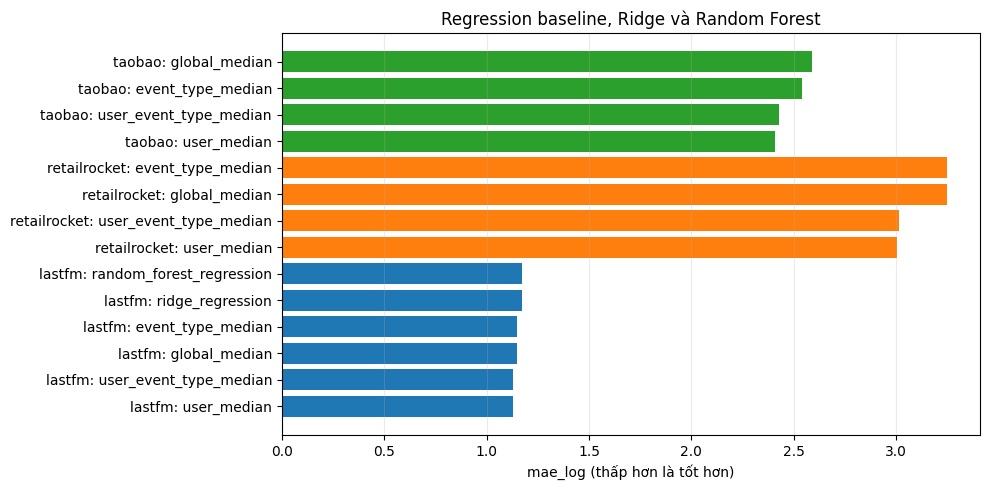

In [68]:
display(display_regression_table(regression_results))

reg_plot_df = regression_results.copy()
fig, ax = plt.subplots(figsize=(10, 5))
for dataset_name, group in reg_plot_df.groupby("dataset", sort=False):
    group = group.sort_values("mae_log")
    ax.barh([f"{dataset_name}: {m}" for m in group["model"]], group["mae_log"])
ax.set_xlabel("mae_log (thấp hơn là tốt hơn)")
ax.set_title("Regression baseline, Ridge và Random Forest")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "regression_mae_log_by_model.png", dpi=160)
plt.show()

### Nhận xét kết quả regression

Bảng và biểu đồ trên tổng hợp kết quả của các mô hình regression cho bài toán dự đoán trực tiếp `delta_t_seconds`. Trong phần này, các baseline thống kê như `global_median`, `user_median`, `event_type_median` và `user_event_type_median` được so sánh với các mô hình học máy gồm `ridge_regression` và `random_forest_regression`. Metric chính được dùng để xếp hạng là `mae_log`, trong đó giá trị càng thấp càng tốt.

Do `delta_t_seconds` có phân phối lệch phải mạnh và tồn tại nhiều khoảng thời gian rất lớn, việc đánh giá trực tiếp trên thang giây hoặc giờ có thể bị ảnh hưởng mạnh bởi outlier. Vì vậy, `mae_log` được chọn làm metric chính. Metric này đo sai số sau khi biến đổi log, nên phản ánh sai lệch theo tỷ lệ độ lớn hơn là sai số tuyệt đối trên thời gian gốc. Có thể diễn giải gần đúng rằng `exp(mae_log)` biểu thị hệ số sai lệch trung bình trên thang thời gian. Ví dụ, với Last.fm, `mae_log` khoảng 1.13 tương ứng với sai lệch trung bình khoảng `exp(1.13) ≈ 3.1` lần trên thang log.

Với **Last.fm**, hai baseline tốt nhất là `user_median` và `user_event_type_median`, cùng đạt `mae_log = 1.1310`. Kết quả này cho thấy lịch sử thời gian của từng user là tín hiệu rất quan trọng trong bài toán next-time prediction. Nói cách khác, mỗi user có nhịp nghe nhạc tương đối riêng, và việc dùng median `delta_t` trong quá khứ của chính user đó đã tạo ra một baseline mạnh. `user_event_type_median` không cải thiện thêm so với `user_median`, vì Last.fm trong notebook này gần như chỉ có một loại hành vi chính là `listen`, nên `event_type` không bổ sung nhiều thông tin.

Các mô hình học máy trên Last.fm chưa vượt được baseline thống kê theo user. `ridge_regression` đạt `mae_log = 1.1731`, còn `random_forest_regression` đạt `mae_log = 1.1753`, đều kém hơn `user_median`. Điều này cho thấy trong thiết lập hiện tại, cả mô hình tuyến tính và mô hình phi tuyến nhẹ đều chưa khai thác được thêm tín hiệu đủ mạnh để vượt qua baseline thống kê. Một nguyên nhân hợp lý là các feature hiện tại còn đơn giản, trong khi `user_median` đã nắm bắt trực tiếp nhịp thời gian cá nhân của user.

Một điểm cần chú ý ở Last.fm là `median_ae_seconds` chỉ khoảng 66 giây, nhưng `mae_hours` lại rất lớn, khoảng 690 giờ. Hai metric này không mâu thuẫn với nhau vì chúng đo hai khía cạnh khác nhau. `median_ae_seconds` dùng trung vị sai số tuyệt đối, nên phản ánh sai số điển hình của đa số mẫu test. Trong khi đó, `mae_hours` là trung bình sai số tuyệt đối trên thang thời gian gốc rồi đổi sang giờ, nên rất nhạy với một số outlier có `delta_t` cực lớn. Điều này cho thấy phần lớn dự đoán có thể khá gần, nhưng một vài trường hợp user quay lại sau thời gian rất dài có thể kéo MAE trên thang gốc lên rất cao.

Với **RetailRocket**, baseline tốt nhất theo `mae_log` là `user_median`, đạt `mae_log = 3.0054`, tiếp theo là `user_event_type_median` với `mae_log = 3.0115`. Hai baseline theo user tốt hơn rõ rệt so với `global_median` và `event_type_median`, cho thấy lịch sử tương tác của từng user vẫn có giá trị. Tuy nhiên, mức `mae_log` trên RetailRocket khá cao, phản ánh rằng dự đoán trực tiếp `delta_t_seconds` trong dữ liệu thương mại điện tử là khó. User có thể tương tác liên tục trong một session ngắn, nhưng cũng có thể quay lại sau nhiều giờ hoặc nhiều ngày. Vì vậy, kết quả regression trên RetailRocket nên được xem là diagnostic phụ; hướng diễn giải chính của dataset này phù hợp hơn với classification theo `time_bucket`.

Với **Taobao**, `user_median` tiếp tục là baseline tốt nhất với `mae_log = 2.4094`, sau đó là `user_event_type_median` với `mae_log = 2.4290`. Các baseline chỉ dựa trên global hoặc event type đều kém hơn, cho thấy yếu tố user-specific vẫn đóng vai trò quan trọng. Tuy vậy, `mae_log` vẫn còn khá cao nếu mục tiêu là dự đoán chính xác thời gian liên tục. Tương tự RetailRocket, Taobao có nhiều loại hành vi và phân phối thời gian không đồng đều, nên classification theo `time_bucket` là hướng đánh giá chính phù hợp hơn regression trực tiếp.

Nhìn tổng thể, kết quả regression cho thấy các baseline thống kê theo user là đối thủ rất mạnh trong bài toán next-time prediction. Việc bổ sung Ridge Regression và Random Forest giúp kiểm tra liệu mô hình học máy tuyến tính hoặc phi tuyến nhẹ có thể cải thiện kết quả hay không. Tuy nhiên, trong thiết lập hiện tại, các mô hình học máy này chưa vượt được baseline tốt nhất theo `mae_log`. Điều này củng cố kết luận rằng bài toán dự đoán thời gian sự kiện tiếp theo không đơn giản chỉ cần thêm mô hình phức tạp hơn; chất lượng feature, đặc trưng chuỗi thời gian, session pattern và khả năng xử lý outlier mới là các yếu tố quan trọng cần được nghiên cứu thêm.

Tóm lại, phần regression cho thấy Last.fm là dataset phù hợp nhất để phân tích next-time prediction liên tục, nhưng ngay cả trên Last.fm, baseline `user_median` vẫn mạnh hơn Ridge Regression và Random Forest. Với RetailRocket và Taobao, regression trực tiếp trên `delta_t_seconds` cho thấy độ khó của target, nhưng kết luận chính nên dựa nhiều hơn vào bài toán classification theo `time_bucket`.


### Actual vs predicted cho regression user baseline

Biểu đồ dưới đây so sánh giá trị thật và giá trị dự đoán trên thang `log1p(delta_t_seconds)`. Ba ô đầu là các case Last.fm đã dùng để so sánh `user_median`, `ridge_regression` và `random_forest_regression`; hai ô cuối bổ sung `user_median` cho RetailRocket và Taobao để xem baseline theo user hoạt động ra sao trên hai dataset thương mại điện tử. Đường chéo biểu thị dự đoán hoàn hảo; điểm càng xa đường chéo thì sai số càng lớn.


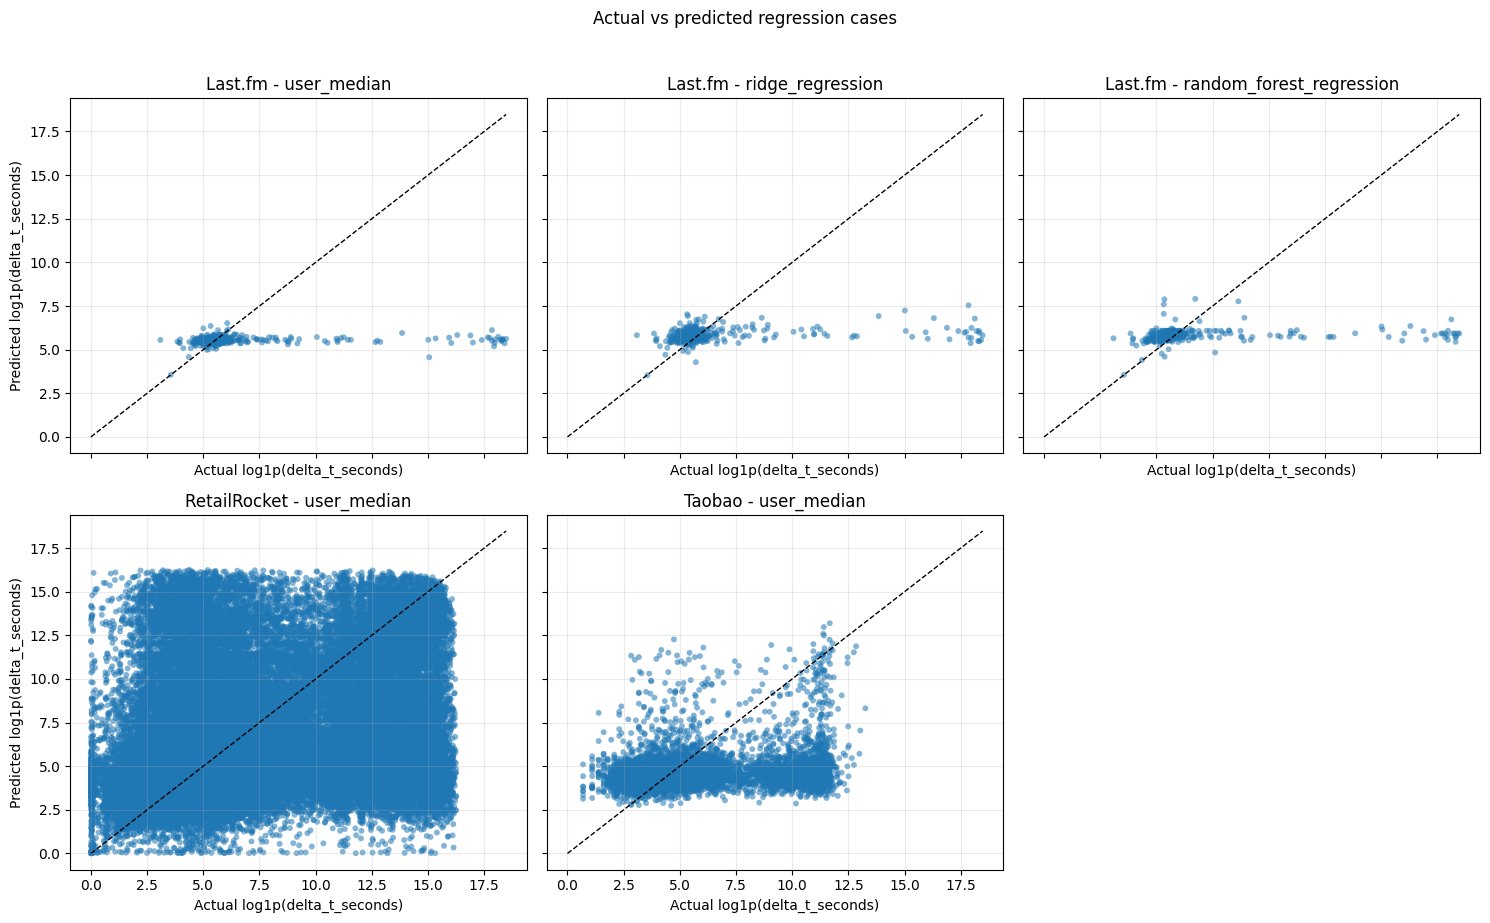

In [69]:
regression_actual_prediction_plot_cases = [
    ("lastfm", "user_median", "Last.fm - user_median"),
    ("lastfm", "ridge_regression", "Last.fm - ridge_regression"),
    ("lastfm", "random_forest_regression", "Last.fm - random_forest_regression"),
    ("retailrocket", "user_median", "RetailRocket - user_median"),
    ("taobao", "user_median", "Taobao - user_median"),
]

n_cols = 3
n_rows = int(np.ceil(len(regression_actual_prediction_plot_cases) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

all_values = []
for dataset_name, model_name, _ in regression_actual_prediction_plot_cases:
    values = regression_prediction_store.get((dataset_name, model_name))
    if values is None:
        continue
    y_true_log, y_pred_log = values
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = np.maximum(np.asarray(y_pred_log, dtype=float), 0)
    finite_mask = np.isfinite(y_true_log) & np.isfinite(y_pred_log)
    all_values.extend(y_true_log[finite_mask].tolist())
    all_values.extend(y_pred_log[finite_mask].tolist())

if all_values:
    axis_min = max(0, float(np.nanmin(all_values)))
    axis_max = float(np.nanmax(all_values))
else:
    axis_min, axis_max = 0, 1

for ax, (dataset_name, model_name, title) in zip(axes, regression_actual_prediction_plot_cases):
    values = regression_prediction_store.get((dataset_name, model_name))
    if values is None:
        ax.text(0.5, 0.5, "Không có prediction", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.set_axis_off()
        continue

    y_true_log, y_pred_log = values
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = np.maximum(np.asarray(y_pred_log, dtype=float), 0)
    finite_mask = np.isfinite(y_true_log) & np.isfinite(y_pred_log)
    y_true_log = y_true_log[finite_mask]
    y_pred_log = y_pred_log[finite_mask]

    ax.scatter(y_true_log, y_pred_log, s=18, alpha=0.55, edgecolors="none")
    ax.plot([axis_min, axis_max], [axis_min, axis_max], color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Actual log1p(delta_t_seconds)")
    ax.grid(alpha=0.25)

for ax in axes[len(regression_actual_prediction_plot_cases):]:
    ax.set_axis_off()

for row_start in range(0, len(axes), n_cols):
    axes[row_start].set_ylabel("Predicted log1p(delta_t_seconds)")

fig.suptitle("Actual vs predicted regression cases", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "actual_vs_predicted_regression_cases.png", dpi=160, bbox_inches="tight")
plt.show()


### Diễn giải biểu đồ actual-vs-predicted cho regression

Các biểu đồ trên so sánh giá trị thật (`actual`) và giá trị dự đoán (`predicted`) của các mô hình regression trên thang `log1p(delta_t_seconds)`. Việc dùng thang log là cần thiết vì `delta_t_seconds` có phân phối lệch phải rất mạnh: phần lớn event có khoảng cách thời gian ngắn, nhưng vẫn tồn tại một số event có khoảng nghỉ rất dài. Nếu vẽ trực tiếp trên thang giây gốc, đa số điểm sẽ bị dồn sát về 0 và các outlier sẽ làm biểu đồ khó đọc.

Đường gạch chéo trong mỗi biểu đồ là đường lý tưởng `predicted = actual`. Nếu mô hình dự đoán tốt, các điểm sẽ nằm gần đường này. Các điểm nằm dưới đường chéo nghĩa là mô hình dự đoán thời gian ngắn hơn thực tế, tức là **underestimate** khoảng cách đến event tiếp theo. Ngược lại, các điểm nằm trên đường chéo nghĩa là mô hình dự đoán thời gian dài hơn thực tế, tức là **overestimate**.

Với **Last.fm**, ba mô hình đại diện gồm `user_median`, `ridge_regression` và `random_forest_regression` đều cho thấy hiện tượng dự đoán bị co về vùng trung tâm của phân phối. Phần lớn giá trị dự đoán nằm quanh `log1p(delta_t_seconds)` khoảng 5--6, tương ứng với các khoảng thời gian vài trăm giây. Trong khi đó, giá trị thật của tập test trải rộng hơn nhiều, có những điểm đạt giá trị log rất lớn. Điều này cho thấy các mô hình dự đoán tương đối hợp lý cho những event có nhịp nghe nhạc ngắn hoặc trung bình, nhưng đánh giá thấp rõ rệt các long-gap event, tức là các trường hợp user quay lại sau một khoảng nghỉ dài.

Với `user_median`, biểu đồ có dạng gần như một dải ngang. Đây là hiện tượng hợp lý vì baseline này dự đoán mỗi user bằng median `delta_t` trong lịch sử train của chính user đó. Nhiều user trong Last.fm có nhịp nghe nhạc điển hình khá ngắn, nên median của họ thường nằm quanh vài trăm giây. Vì vậy, khi event test có khoảng cách thời gian bình thường, dự đoán có thể gần giá trị thật. Tuy nhiên, khi event cuối của user xảy ra sau một khoảng nghỉ rất dài, `user_median` vẫn dự đoán theo nhịp cũ, khiến các điểm nằm xa dưới đường chéo.

Với `ridge_regression`, các điểm phân tán hơn so với `user_median`, nhưng mô hình vẫn chủ yếu dự đoán quanh vùng trung tâm. Điều này cho thấy mô hình tuyến tính có học thêm một số biến thiên từ feature, nhưng chưa đủ để nhận biết các trường hợp long-gap. `random_forest_regression` cũng có kết quả tương tự. Mặc dù Random Forest là mô hình phi tuyến và có khả năng học các tương tác phức tạp hơn Ridge Regression, dự đoán của nó vẫn tập trung quanh vùng thời gian phổ biến. Điều này cho thấy trong thiết lập feature hiện tại, mô hình phi tuyến nhẹ vẫn chưa có đủ tín hiệu để phân biệt khi nào user sẽ quay lại sau một khoảng nghỉ rất dài.

Hiện tượng này có thể được gọi là **prediction shrinkage toward the central tendency** hoặc **regression to the mean**. Nói cách khác, mô hình không trải rộng prediction theo toàn bộ miền giá trị thật của `delta_t`, mà chủ yếu dự đoán quanh vùng thời gian thường gặp. Đây cũng là một dạng **underestimation of the right tail**, vì các event thuộc phần đuôi phải của phân phối, tức là các khoảng nghỉ rất dài, thường bị dự đoán thấp hơn thực tế.

Với **RetailRocket**, biểu đồ của model regression tốt nhất cho thấy các điểm phân tán rất rộng và không bám rõ đường chéo. Điều này cho thấy quan hệ giữa actual và predicted trên thang log không ổn định. Dữ liệu thương mại điện tử có đặc điểm khác với nghe nhạc: user có thể tương tác liên tục trong một session rất ngắn, nhưng cũng có thể quay lại sau nhiều giờ hoặc nhiều ngày. Vì vậy, việc dự đoán trực tiếp `delta_t_seconds` bằng regression trở nên nhiễu và khó diễn giải. Dù `user_median` có thể là baseline tốt nhất theo `mae_log`, biểu đồ cho thấy nó chưa thật sự dự đoán chính xác thời điểm quay lại của user.

Với **Taobao**, biểu đồ cũng cho thấy dự đoán bị co về một vùng tương đối hẹp, trong khi actual trải rộng hơn. Điều này phản ánh cùng một vấn đề: mô hình học được nhịp tương tác phổ biến, nhưng không dự đoán tốt toàn bộ miền thời gian, đặc biệt là các khoảng nghỉ dài hơn. Taobao có nhiều loại hành vi như `pv`, `cart`, `fav`, `buy`, nên thời gian giữa các event có thể phụ thuộc vào ngữ cảnh hành vi phức tạp hơn những gì baseline regression hiện tại mô tả được.

Các biểu đồ này giải thích vì sao `median_ae_seconds` có thể thấp trong khi `mae_hours` lại cao. `median_ae_seconds` phản ánh sai số điển hình của đa số mẫu, còn `mae_hours` là trung bình sai số tuyệt đối trên thang thời gian gốc nên bị kéo lên bởi một số ít outlier có sai số rất lớn. Nói cách khác, mô hình có thể dự đoán tương đối ổn cho các event thông thường, nhưng chỉ cần sai rất lớn ở một vài long-gap event thì MAE trên thang giờ sẽ tăng mạnh.

Tóm lại, actual-vs-predicted plot cho thấy regression trực tiếp trên `delta_t_seconds` có giới hạn rõ ràng. Với Last.fm, regression vẫn có ý nghĩa vì phần lớn hành vi nghe nhạc có nhịp ngắn và tương đối ổn định, nhưng các mô hình hiện tại vẫn chưa xử lý tốt long-gap event. Với RetailRocket và Taobao, regression chủ yếu nên được xem là phân tích phụ để minh họa độ khó của target liên tục; hướng đánh giá chính phù hợp hơn là classification theo `time_bucket`, nơi các khoảng thời gian được gom thành các mức rời rạc dễ diễn giải hơn.


## Kết quả classification

`macro_f1` là metric chính vì phân phối time bucket có thể mất cân bằng. Accuracy và weighted-F1 được hiển thị để tham khảo, nhưng không được dùng làm kết luận chính.

,dataset,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,test_rows_used
5,retailrocket,random_forest_classifier,0.4254,0.2432,0.2341,0.4408,74997
3,retailrocket,user_event_type_majority,0.4833,0.2182,0.2222,0.4599,74997
1,retailrocket,user_majority,0.4843,0.2179,0.2221,0.4601,74997
4,retailrocket,logistic_regression,0.4370,0.2256,0.2140,0.4399,74997
0,retailrocket,majority_class,0.5463,0.1429,0.1009,0.3860,74997
2,retailrocket,event_type_majority,0.5463,0.1429,0.1009,0.3860,74997
11,taobao,random_forest_classifier,0.3847,0.2941,0.2347,0.4203,4921
9,taobao,user_event_type_majority,0.5572,0.1956,0.1498,0.4349,4921
7,taobao,user_majority,0.5631,0.1884,0.1386,0.4263,4921
10,taobao,logistic_regression,0.1211,0.1395,0.1217,0.1507,4921


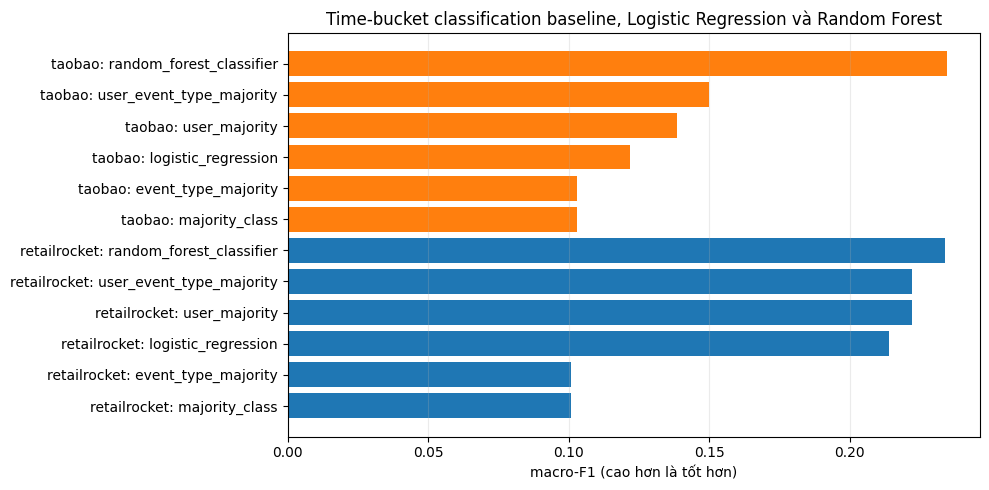

In [70]:
display(display_classification_table(classification_results))

cls_plot_df = classification_results[classification_results["dataset"].isin(["retailrocket", "taobao"])].copy()
fig, ax = plt.subplots(figsize=(10, 5))
for dataset_name, group in cls_plot_df.groupby("dataset", sort=False):
    group = group.sort_values("macro_f1", ascending=True)
    ax.barh([f"{dataset_name}: {m}" for m in group["model"]], group["macro_f1"])
ax.set_xlabel("macro-F1 (cao hơn là tốt hơn)")
ax.set_title("Time-bucket classification baseline, Logistic Regression và Random Forest")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "classification_macro_f1_by_model.png", dpi=160)
plt.show()

### Nhận xét kết quả classification theo `time_bucket`

Bảng và biểu đồ trên so sánh các baseline classification với Logistic Regression và Random Forest cho bài toán dự đoán `time_bucket`. Khác với regression, phần này không dự đoán trực tiếp số giây đến event tiếp theo, mà phân loại khoảng thời gian thành các bucket rời rạc như `<5m`, `5m_30m`, `30m_1h`, `1h_6h`, `6h_1d`, `1d_7d` và `gt_7d`. Metric chính được dùng để xếp hạng là `macro_f1`, vì phân phối `time_bucket` bị mất cân bằng mạnh và accuracy có thể gây hiểu nhầm.

Với **RetailRocket**, `random_forest_classifier` đạt `macro_f1 = 0.2341`, cao hơn `user_event_type_majority` với `macro_f1 = 0.2222`, `user_majority` với `macro_f1 = 0.2221` và `logistic_regression` với `macro_f1 = 0.2140`. Điều này cho thấy Random Forest đã cải thiện nhẹ so với cả baseline thống kê mạnh nhất và mô hình tuyến tính. Ngoài ra, `balanced_accuracy` của Random Forest đạt 0.2432, cũng cao hơn các baseline thống kê theo user. Đây là tín hiệu cho thấy mô hình phi tuyến có khả năng phân biệt các bucket tốt hơn một chút, đặc biệt là khi xét công bằng hơn giữa các lớp.

Tuy nhiên, accuracy của Random Forest trên RetailRocket chỉ đạt 0.4254, thấp hơn `majority_class` và `user_majority`. Điều này không có nghĩa Random Forest kém hơn về mặt chính. Nguyên nhân là `accuracy` bị ảnh hưởng mạnh bởi bucket phổ biến nhất. Một mô hình đoán nhiều vào bucket phổ biến như `<5m` có thể đạt accuracy cao, nhưng lại bỏ qua các bucket ít xuất hiện. Ngược lại, Random Forest có thể phân bổ dự đoán sang nhiều bucket hơn, làm accuracy giảm nhưng `macro_f1` và `balanced_accuracy` tăng. Vì vậy, với dữ liệu mất cân bằng, `macro_f1` là metric phù hợp hơn để đánh giá chất lượng tổng thể giữa các bucket.

Với **Taobao**, Random Forest cải thiện rõ hơn. `random_forest_classifier` đạt `macro_f1 = 0.2347`, cao hơn đáng kể so với `user_event_type_majority` với `macro_f1 = 0.1498`, `user_majority` với `macro_f1 = 0.1386` và `logistic_regression` với `macro_f1 = 0.1217`. `balanced_accuracy` cũng tăng lên 0.2941, cao hơn các baseline còn lại. Điều này cho thấy với Taobao, các quan hệ phi tuyến giữa feature và `time_bucket` có ích hơn so với các rule thống kê đơn giản theo user hoặc event type.

Dù vậy, accuracy của Random Forest trên Taobao chỉ đạt 0.3847, thấp hơn các majority baseline khoảng 0.56. Đây là hiện tượng tương tự RetailRocket: các baseline majority đạt accuracy cao vì dự đoán nhiều vào bucket phổ biến, nhưng macro-F1 thấp do không dự đoán tốt các bucket thiểu số. Random Forest hy sinh một phần accuracy để cải thiện khả năng dự đoán cân bằng hơn giữa các bucket, nên macro-F1 và balanced accuracy tốt hơn. Vì mục tiêu của classification là đánh giá khả năng phân biệt nhiều mức thời gian, Random Forest nên được xem là mô hình tốt hơn theo metric chính.

Kết quả này cho thấy việc bổ sung mô hình phi tuyến nhẹ là có ý nghĩa đối với classification. Khác với regression, nơi Random Forest chưa vượt được `user_median`, trong bài toán `time_bucket classification`, Random Forest vượt baseline tốt nhất trên cả RetailRocket và Taobao theo `macro_f1`. Điều này gợi ý rằng gom `delta_t_seconds` thành các bucket rời rạc giúp mô hình học được pattern ổn định hơn so với dự đoán thời gian liên tục.

Tuy nhiên, giá trị `macro_f1` tuyệt đối vẫn còn thấp, khoảng 0.23 trên cả hai dataset. Điều này cho thấy bài toán vẫn khó: các bucket thời gian bị mất cân bằng, temporal test set có nhiều long-gap event hơn train, và feature hiện tại vẫn còn đơn giản. Random Forest cải thiện kết quả, nhưng chưa đủ để xem là mô hình mạnh cuối cùng. Kết quả phù hợp hơn với vai trò của notebook này: thiết lập baseline và kiểm tra xem mô hình học máy đơn giản, bao gồm cả mô hình phi tuyến nhẹ, có vượt được baseline thống kê hay không.

Tóm lại, phần classification cho thấy Random Forest là mô hình tốt nhất theo `macro_f1` trên cả RetailRocket và Taobao. Điều này chứng minh rằng mô hình phi tuyến nhẹ có thể khai thác thêm tín hiệu so với Logistic Regression và majority baseline. Tuy nhiên, do macro-F1 vẫn thấp, hướng mở rộng tiếp theo nên tập trung vào feature lịch sử gần nhất, session-level features, xử lý mất cân bằng class, hoặc các mô hình sequence-aware nếu muốn cải thiện khả năng dự đoán các bucket thời gian dài.

## Confusion matrix

Confusion matrix được đọc theo hàng là nhãn thật và cột là nhãn dự đoán. Các ô trên đường chéo là dự đoán đúng, còn các ô ngoài đường chéo là lỗi. Nếu phần lớn dự đoán dồn vào một cột, mô hình đang bị lệch về một bucket phổ biến. Điều này giải thích vì sao accuracy có thể tương đối cao nhưng macro-F1 vẫn thấp.

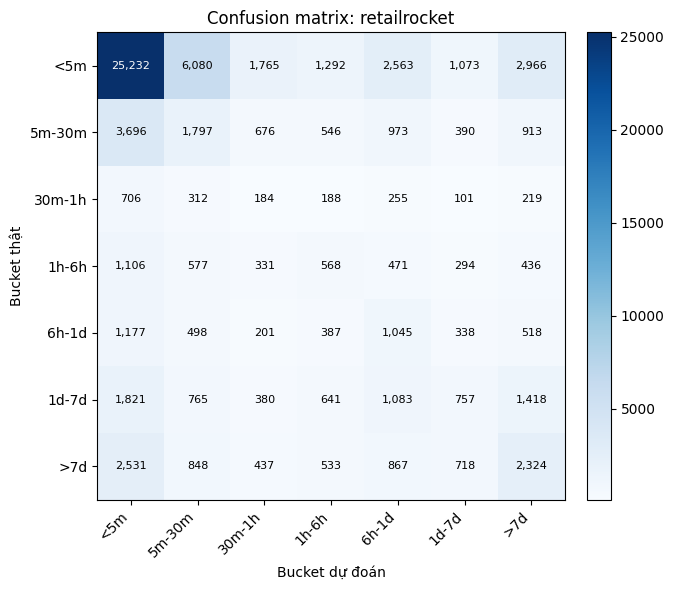

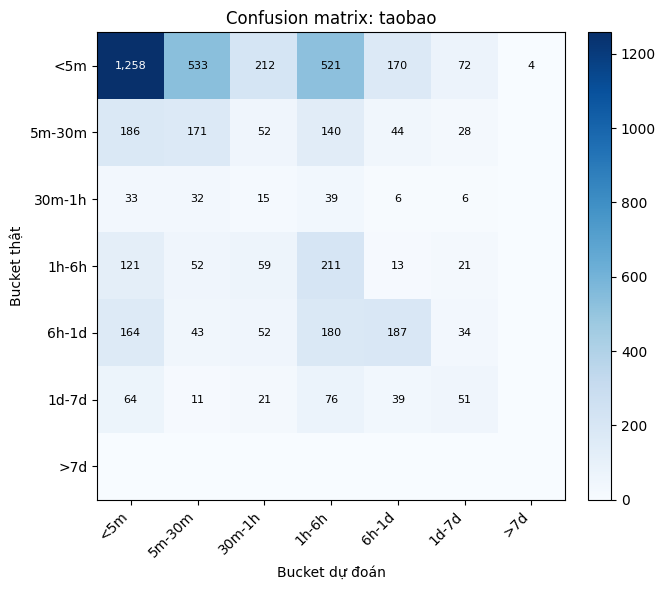

In [71]:
for dataset_name in ["retailrocket", "taobao"]:
    if dataset_name in confusion_matrices:
        plot_confusion_matrix(confusion_matrices[dataset_name], dataset_name)

### Diễn giải confusion matrix cho classification

Hai confusion matrix trên mô tả các kiểu nhầm lẫn của model classification theo `time_bucket` trên RetailRocket và Taobao. Mỗi hàng là bucket thật, mỗi cột là bucket được dự đoán. Các ô nằm trên đường chéo chính là dự đoán đúng; các ô ngoài đường chéo là các trường hợp model dự đoán sai. Vì các bucket thời gian bị mất cân bằng mạnh, confusion matrix giúp nhìn rõ model đang sai ở bucket nào, thay vì chỉ dựa vào một metric tổng hợp như accuracy hoặc macro-F1.

Với **RetailRocket**, model dự đoán đúng khá nhiều mẫu thuộc bucket `<5m`, với 25,232 trường hợp nằm trên đường chéo. Điều này hợp lý vì `<5m` là bucket phổ biến nhất trong tập test. Tuy nhiên, model vẫn nhầm một lượng lớn mẫu `<5m` sang các bucket khác như `5m-30m`, `6h-1d` và `>7d`. Điều này cho thấy dù model nhận diện được nhiều tương tác ngắn, ranh giới giữa các bucket thời gian vẫn chưa thật sự rõ.

Một điểm đáng chú ý ở RetailRocket là các bucket dài như `1d-7d` và `>7d` vẫn bị dự đoán nhầm khá nhiều về bucket ngắn hơn, đặc biệt là `<5m` hoặc `5m-30m`. Ví dụ, nhiều mẫu thật sự thuộc `>7d` bị dự đoán thành `<5m`, trong khi cũng có một phần được dự đoán đúng là `>7d`. Điều này cho thấy model có học được một phần tín hiệu của long-gap event, nhưng chưa đủ ổn định. Nói cách khác, Random Forest đã phân bổ dự đoán sang nhiều bucket hơn majority baseline, nhưng vẫn gặp khó trong việc phân biệt chính xác các khoảng thời gian dài.

Với **Taobao**, model dự đoán đúng nhiều nhất ở bucket `<5m`, với 1,258 trường hợp đúng. Tuy nhiên, các mẫu `<5m` cũng bị nhầm đáng kể sang `5m-30m` và `1h-6h`. Điều này cho thấy bucket ngắn vẫn chiếm ưu thế, nhưng model không chỉ dự đoán một class duy nhất. Đây là lý do Random Forest có macro-F1 tốt hơn majority baseline: nó cố gắng phân biệt nhiều bucket hơn, thay vì chỉ tập trung vào bucket phổ biến nhất.

Ở Taobao, các bucket trung bình và dài như `1h-6h`, `6h-1d` và `1d-7d` vẫn khó dự đoán. Bucket `1h-6h` có 211 mẫu đúng, nhưng cũng bị nhầm sang `<5m`, `5m-30m` và `30m-1h`. Bucket `6h-1d` có 187 mẫu đúng nhưng bị nhầm nhiều sang `<5m` và `1h-6h`. Điều này cho thấy model có xu hướng nhầm giữa các bucket gần nhau hoặc nhầm long-gap về bucket ngắn hơn. Đặc biệt, Taobao gần như không có mẫu thật thuộc `>7d`, nên hàng `>7d` gần như trống; do đó không nên diễn giải hiệu quả của model trên bucket này.

Nhìn chung, confusion matrix cho thấy Random Forest không chỉ học majority class mà đã phân phối dự đoán sang nhiều bucket thời gian khác nhau. Đây là lý do `macro_f1` và `balanced_accuracy` được cải thiện so với các baseline thống kê. Tuy nhiên, các lỗi ngoài đường chéo vẫn còn nhiều, đặc biệt ở các bucket ít mẫu và các bucket dài. Điều này giải thích vì sao macro-F1 dù tốt nhất vẫn chỉ khoảng 0.23: model có cải thiện tính cân bằng giữa các class, nhưng vẫn chưa dự đoán chính xác được toàn bộ phổ thời gian.

Tóm lại, confusion matrix củng cố kết luận rằng classification theo `time_bucket` phù hợp hơn regression trực tiếp cho RetailRocket và Taobao, nhưng bài toán vẫn khó. Random Forest đã giảm phụ thuộc vào bucket phổ biến và cải thiện khả năng dự đoán các bucket khác, song vẫn thường nhầm giữa bucket ngắn, trung bình và dài. Các hướng cải thiện tiếp theo nên tập trung vào feature lịch sử gần nhất, session-level features, xử lý mất cân bằng class, hoặc mô hình sequence-aware để phân biệt tốt hơn các long-gap event.

## Final modeling summary

Bảng cuối chỉ so sánh model với baseline theo primary metric: `mae_log` cho regression và `macro_f1` cho classification. Không kết luận model thắng nếu chỉ tốt hơn ở metric phụ.

In [72]:
display(final_summary.round({"baseline_score": 4, "model_score": 4}))

,dataset,primary_task,best_baseline,best_model,primary_metric,baseline_score,model_score,model_beats_baseline,main_interpretation,limitation,recommended_next_step
0,lastfm,log_delta_regression,user_median,ridge_regression,mae_log,1.1310,1.1731,False,ridge_regression có rmse_log thấp hơn nhưng kh...,Kết quả phụ thuộc vào user-level sample và fea...,Thêm user history feature không leakage và kiể...
1,retailrocket,time_bucket_classification,user_event_type_majority,random_forest_classifier,macro_f1,0.2222,0.2341,True,Logistic Regression vượt majority baseline the...,Accuracy có thể cao do label imbalance; macro-...,"Bổ sung session feature, rolling user feature,..."
2,taobao,time_bucket_classification,user_event_type_majority,random_forest_classifier,macro_f1,0.1498,0.2347,True,Logistic Regression vượt majority baseline the...,Accuracy có thể cao do label imbalance; macro-...,"Bổ sung session feature, rolling user feature,..."


### Tổng kết kết quả mô hình

Bảng trên tổng hợp kết quả chính của notebook theo từng dataset và từng loại bài toán. Với Last.fm, bài toán chính là regression trên `log_delta_t`, sử dụng `mae_log` làm metric chính. Baseline tốt nhất là `user_median` với `mae_log = 1.1310`, trong khi mô hình học máy tốt nhất là `ridge_regression` với `mae_log = 1.1731`. Vì `mae_log` càng thấp càng tốt, Ridge Regression chưa vượt được baseline thống kê theo user. Điều này cho thấy nhịp nghe nhạc cá nhân trong lịch sử train là một tín hiệu rất mạnh, và các feature hiện tại chưa đủ để mô hình học máy cải thiện thêm.

Với RetailRocket và Taobao, bài toán chính được diễn giải dưới dạng classification theo `time_bucket`, sử dụng `macro_f1` làm metric chính. Sau khi bổ sung Random Forest, mô hình phi tuyến nhẹ này trở thành mô hình tốt nhất trên cả hai dataset. Trên RetailRocket, Random Forest đạt `macro_f1 = 0.2341`, cao hơn baseline tốt nhất `user_event_type_majority` với `macro_f1 = 0.2222`. Trên Taobao, Random Forest đạt `macro_f1 = 0.2347`, cao hơn rõ rệt so với baseline tốt nhất `user_event_type_majority` với `macro_f1 = 0.1498`.

Điều này cho thấy classification theo `time_bucket` phù hợp hơn với dữ liệu thương mại điện tử so với regression trực tiếp trên `delta_t_seconds`. Random Forest có thể khai thác các tương tác phi tuyến giữa feature tốt hơn Logistic Regression và các baseline thống kê. Tuy nhiên, macro-F1 tuyệt đối vẫn còn thấp, khoảng 0.23, cho thấy bài toán vẫn khó do mất cân bằng bucket thời gian, temporal distribution shift và feature hiện tại còn đơn giản.

Kết luận chung là: mô hình học máy đơn giản chưa vượt được baseline thống kê trong regression trên Last.fm, nhưng mô hình phi tuyến nhẹ đã cải thiện kết quả classification trên RetailRocket và Taobao. Do đó, hướng phát triển tiếp theo nên tập trung vào feature lịch sử gần nhất, session-level features, xử lý mất cân bằng class và các mô hình sequence-aware để dự đoán tốt hơn các khoảng thời gian dài.